## Import Libraries

In [1]:
import pandas as pd
from pandas.plotting import scatter_matrix
import numpy as np
import csv
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

## Get Data

In [2]:
# https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption
data_url = "https://archive.ics.uci.edu/static/public/235/data.csv"
def load_power_data():
    csv_path = data_url
    return pd.read_csv(csv_path, sep=',', low_memory=False)

In [3]:
power = load_power_data()

## Data Inspection

### Check the data type of the columns

In [4]:
power.info()

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   str    
 1   Time                   str    
 2   Global_active_power    str    
 3   Global_reactive_power  str    
 4   Voltage                str    
 5   Global_intensity       str    
 6   Sub_metering_1         str    
 7   Sub_metering_2         str    
 8   Sub_metering_3         float64
dtypes: float64(1), str(8)
memory usage: 142.5 MB


### Convert the data type of the columns

In [5]:
# Convert the data type of the columns to numeric, coercing errors to NaN
power["Sub_metering_1"] = pd.to_numeric(power["Sub_metering_1"], errors='coerce')
power["Sub_metering_2"] = pd.to_numeric(power["Sub_metering_2"], errors='coerce')
power["Sub_metering_3"] = pd.to_numeric(power["Sub_metering_3"], errors='coerce')
power["Voltage"] = pd.to_numeric(power["Voltage"], errors='coerce')
power["Global_active_power"] = pd.to_numeric(power["Global_active_power"], errors='coerce')
power["Global_reactive_power"] = pd.to_numeric(power["Global_reactive_power"], errors='coerce')
power["Global_intensity"] = pd.to_numeric(power["Global_intensity"], errors='coerce')

# Combine the Date and Time columns into a single datetime column > feature engineering
power['DateTime'] = pd.to_datetime(power['Date'] + ' ' + power['Time'], errors='coerce', format="%d/%m/%Y %H:%M:%S")


In [6]:
# Get the year, month, and day from the DateTime column
power["year"] = power["DateTime"].dt.year
power["month"] = power["DateTime"].dt.month
power["day"] = power["DateTime"].dt.day

In [7]:
power.info()

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 13 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Date                   str           
 1   Time                   str           
 2   Global_active_power    float64       
 3   Global_reactive_power  float64       
 4   Voltage                float64       
 5   Global_intensity       float64       
 6   Sub_metering_1         float64       
 7   Sub_metering_2         float64       
 8   Sub_metering_3         float64       
 9   DateTime               datetime64[us]
 10  year                   int32         
 11  month                  int32         
 12  day                    int32         
dtypes: datetime64[us](1), float64(7), int32(3), str(2)
memory usage: 182.1 MB


## Summary Inspection

In [8]:
power.shape

(2075259, 13)

In [9]:
power.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,DateTime,year,month,day
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00,2006,12,16
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00,2006,12,16
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00,2006,12,16
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00,2006,12,16
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00,2006,12,16


In [10]:
power.describe(include='all')

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,DateTime,year,month,day
count,2075259,2075259,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2075259,2.075259e+06,2.075259e+06,2.075259e+06
unique,1442,1440,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,17/12/2006,17:24:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1440,1442,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00,2008-12-06 07:13:00,2.008437e+03,6.450359e+00,1.577363e+01
min,NaN,NaN,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,2006-12-16 17:24:00,2.006000e+03,1.000000e+00,1.000000e+00
25%,NaN,NaN,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2007-12-12 00:18:30,2.007000e+03,3.000000e+00,8.000000e+00
50%,NaN,NaN,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2008-12-06 07:13:00,2.008000e+03,6.000000e+00,1.600000e+01
75%,NaN,NaN,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01,2009-12-01 14:07:30,2.009000e+03,9.000000e+00,2.300000e+01
max,NaN,NaN,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01,2010-11-26 21:02:00,2.010000e+03,1.200000e+01,3.100000e+01


In [11]:
power.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,DateTime,year,month,day
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2075259,2.075259e+06,2.075259e+06,2.075259e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00,2008-12-06 07:13:00,2.008437e+03,6.450359e+00,1.577363e+01
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,2006-12-16 17:24:00,2.006000e+03,1.000000e+00,1.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2007-12-12 00:18:30,2.007000e+03,3.000000e+00,8.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2008-12-06 07:13:00,2.008000e+03,6.000000e+00,1.600000e+01
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01,2009-12-01 14:07:30,2.009000e+03,9.000000e+00,2.300000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01,2010-11-26 21:02:00,2.010000e+03,1.200000e+01,3.100000e+01
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00,NaN,1.128677e+00,3.415762e+00,8.787773e+00


## Visual Inspection

array([[<Axes: title={'center': 'Global_active_power'}>,
        <Axes: title={'center': 'Global_reactive_power'}>,
        <Axes: title={'center': 'Voltage'}>],
       [<Axes: title={'center': 'Global_intensity'}>,
        <Axes: title={'center': 'Sub_metering_1'}>,
        <Axes: title={'center': 'Sub_metering_2'}>],
       [<Axes: title={'center': 'Sub_metering_3'}>,
        <Axes: title={'center': 'DateTime'}>,
        <Axes: title={'center': 'year'}>],
       [<Axes: title={'center': 'month'}>,
        <Axes: title={'center': 'day'}>, <Axes: >]], dtype=object)

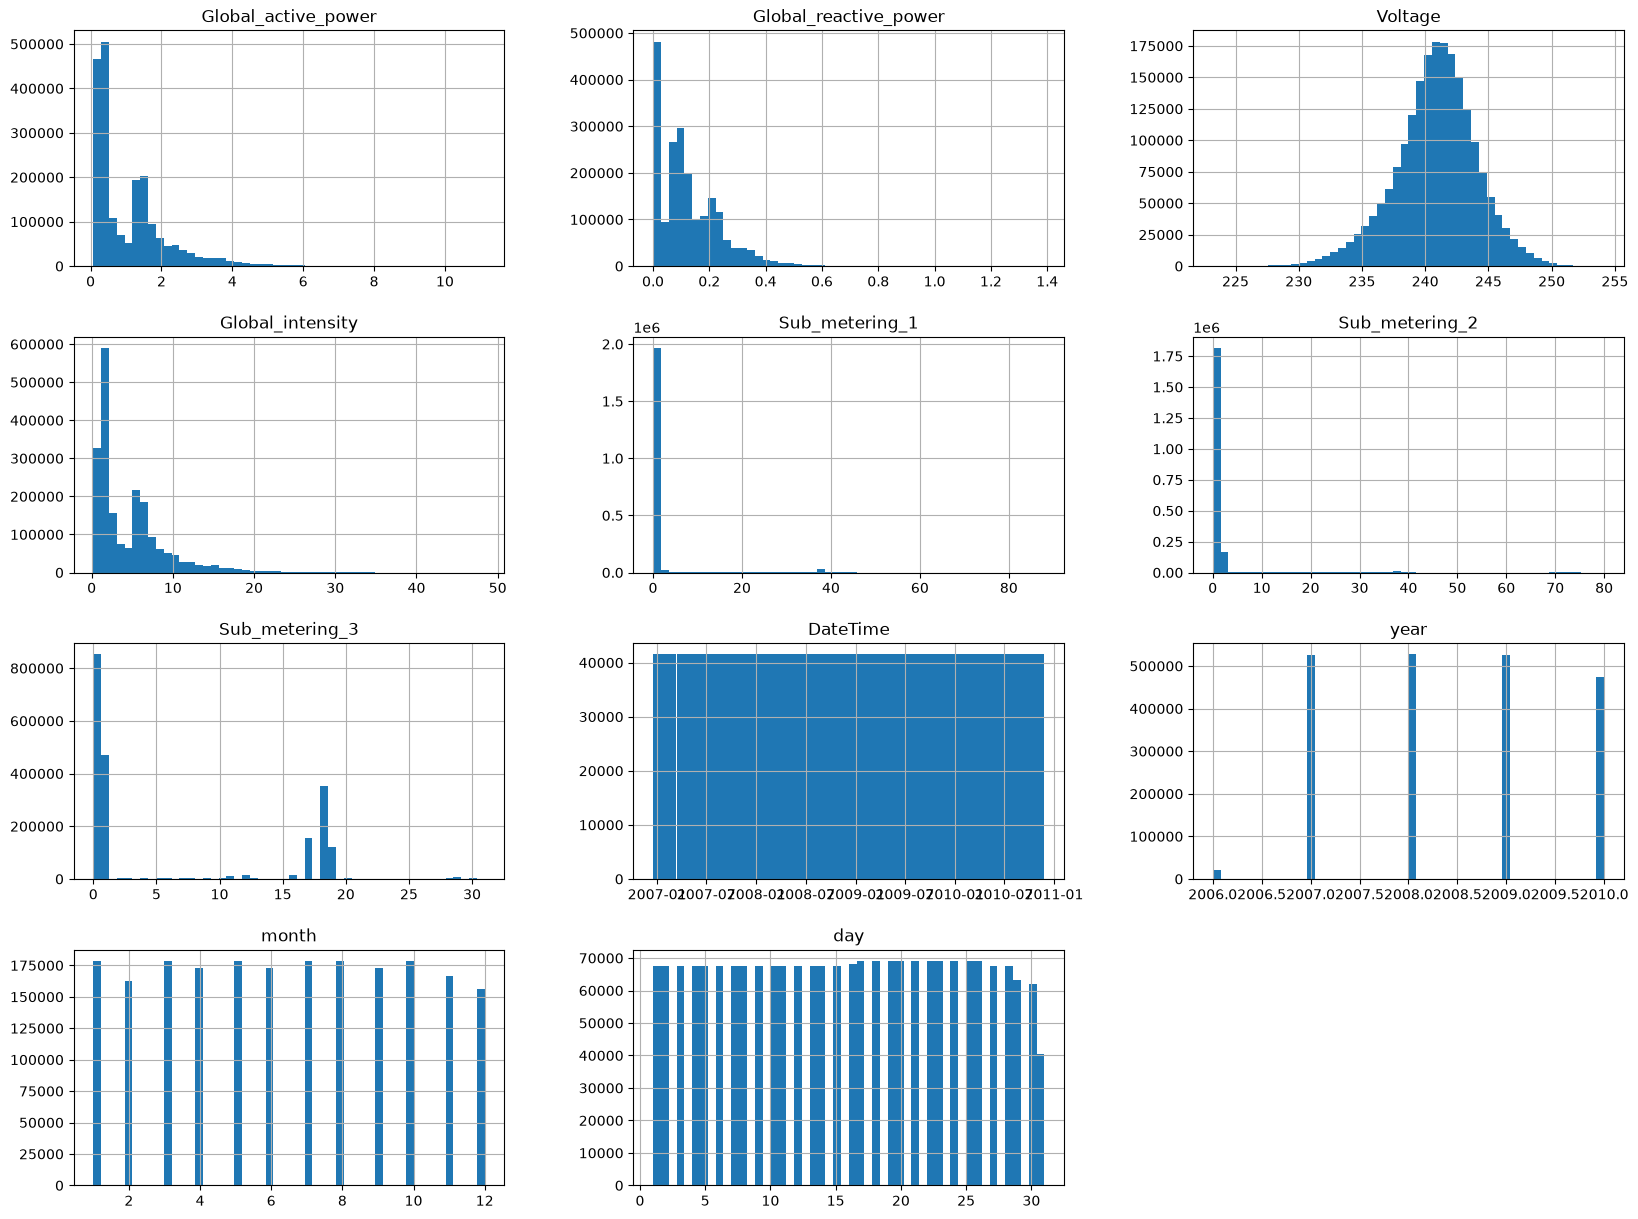

In [12]:
power.hist(bins=50, figsize=(20,15))

In [13]:
attributes = ["Global_active_power", "Global_reactive_power", "Voltage", "Global_intensity", "Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]
#scatter_matrix(power[attributes], figsize=(12, 8))

array([[<Axes: xlabel='Global_active_power', ylabel='Global_active_power'>,
        <Axes: xlabel='Global_reactive_power', ylabel='Global_active_power'>,
        <Axes: xlabel='Voltage', ylabel='Global_active_power'>,
        <Axes: xlabel='Global_intensity', ylabel='Global_active_power'>,
        <Axes: xlabel='Sub_metering_1', ylabel='Global_active_power'>,
        <Axes: xlabel='Sub_metering_2', ylabel='Global_active_power'>,
        <Axes: xlabel='Sub_metering_3', ylabel='Global_active_power'>],
       [<Axes: xlabel='Global_active_power', ylabel='Global_reactive_power'>,
        <Axes: xlabel='Global_reactive_power', ylabel='Global_reactive_power'>,
        <Axes: xlabel='Voltage', ylabel='Global_reactive_power'>,
        <Axes: xlabel='Global_intensity', ylabel='Global_reactive_power'>,
        <Axes: xlabel='Sub_metering_1', ylabel='Global_reactive_power'>,
        <Axes: xlabel='Sub_metering_2', ylabel='Global_reactive_power'>,
        <Axes: xlabel='Sub_metering_3', ylabel='Gl

Error in callback <function _draw_all_if_interactive at 0x00000222E7F12F00> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x00000222A913F740> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

## Data Cleaning

In [15]:
# fill in missing values
imputer = SimpleImputer(strategy="median")
imputer.fit(power[attributes])
power[attributes] = imputer.transform(power[attributes])

In [16]:
power.isna().sum()

Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
DateTime                 0
year                     0
month                    0
day                      0
dtype: int64

In [17]:
#(power[["Global_active_power", "month", "year", "day", "Voltage"]], figsize=(12, 8))

array([[<Axes: xlabel='Global_active_power', ylabel='Global_active_power'>,
        <Axes: xlabel='month', ylabel='Global_active_power'>,
        <Axes: xlabel='year', ylabel='Global_active_power'>,
        <Axes: xlabel='day', ylabel='Global_active_power'>,
        <Axes: xlabel='Voltage', ylabel='Global_active_power'>],
       [<Axes: xlabel='Global_active_power', ylabel='month'>,
        <Axes: xlabel='month', ylabel='month'>,
        <Axes: xlabel='year', ylabel='month'>,
        <Axes: xlabel='day', ylabel='month'>,
        <Axes: xlabel='Voltage', ylabel='month'>],
       [<Axes: xlabel='Global_active_power', ylabel='year'>,
        <Axes: xlabel='month', ylabel='year'>,
        <Axes: xlabel='year', ylabel='year'>,
        <Axes: xlabel='day', ylabel='year'>,
        <Axes: xlabel='Voltage', ylabel='year'>],
       [<Axes: xlabel='Global_active_power', ylabel='day'>,
        <Axes: xlabel='month', ylabel='day'>,
        <Axes: xlabel='year', ylabel='day'>,
        <Axes: xlabel=

Error in callback <function _draw_all_if_interactive at 0x00000222E7F12F00> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x00000222A913F740> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [18]:
power.info()

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 13 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Date                   str           
 1   Time                   str           
 2   Global_active_power    float64       
 3   Global_reactive_power  float64       
 4   Voltage                float64       
 5   Global_intensity       float64       
 6   Sub_metering_1         float64       
 7   Sub_metering_2         float64       
 8   Sub_metering_3         float64       
 9   DateTime               datetime64[us]
 10  year                   int32         
 11  month                  int32         
 12  day                    int32         
dtypes: datetime64[us](1), float64(7), int32(3), str(2)
memory usage: 182.1 MB


In [19]:
power = power.drop(["Date", "Time", "DateTime"], axis=1)

## Split the data into train and test sets

In [20]:
# Split the dataset into train and test sets 80/20
# Could use stratified split
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(power, test_size=0.2, random_state=24)

## Apply Linear Regression Model

In [21]:
power_features = train_set.drop("Global_active_power", axis=1) # Drop Global_active_power column for features
power_labels = train_set["Global_active_power"].copy() # Copy Global_active_power column for labels

In [22]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
# Training the model on the features and the target
lin_reg.fit(power_features, power_labels)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[-0.18, 0. , 0.24,..., 0. , 0. , 0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['Global_reactive_power','Voltage','Global_intensity',...,'year','month', 'day']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.156
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(9)


## Accuracy of the model

In [27]:
from sklearn.metrics import mean_squared_error

#Get the RMSE for the model
gPower_predictions = lin_reg.predict(power_features)
lin_mse = mean_squared_error(power_labels, gPower_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(0.0403607370658686)

In [28]:
from sklearn.metrics import mean_absolute_error

#Get the MAE for the model
lin_mae = mean_absolute_error(power_labels, gPower_predictions)
lin_mae

0.025597283345540303

## Better Evaluation Using Cross-Validation

In [29]:
from sklearn.model_selection import cross_val_score

# Cross-validation with 10 folds
scores = cross_val_score(lin_reg, power_features, power_labels,
                         scoring="neg_mean_squared_error", cv=10)
# Get the RMSE for the model
lin_reg_rmse_scores = np.sqrt(-scores)

In [30]:
# Display the scores, score mean, and score standard deviation
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

display_scores(lin_reg_rmse_scores)

Scores: [0.04057875 0.04062943 0.04007354 0.04069968 0.03992522 0.04075163
 0.04015361 0.04021545 0.04015391 0.04042164]
Mean: 0.04036028561681966
Standard deviation: 0.00027749838604905806


## Apply the model to the test set

In [31]:
X_test = test_set.drop("Global_active_power", axis=1) # Drop Global_active_power column for features
Y_test = test_set["Global_active_power"].copy() # Copy Global_active_power column for labels

In [33]:
final_predictions = lin_reg.predict(X_test)

In [34]:
final_mse = mean_squared_error(Y_test, final_predictions)
final_rmse = np.sqrt(final_mse)
final_rmse

np.float64(0.040354427171289495)

In [35]:
final_mae = mean_absolute_error(Y_test, final_predictions)
final_mae

0.02557678717525744